In [1]:
import numpy as np
import pandas as pd
import ast
import xgboost as xgb
import shap
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from pymatgen.core import Element

In [2]:
INPUT_CSV = "./data/lightweight_fm_candidates_practical.csv"
TARGET = "magnetic_performance_index"

Build a physics-informed feature set from raw MP fields.
Avoids leaking the target itself 

(e.g. don't include total_magnetization
or cell_mass directly, since target is derived from them).

Group Alignment:
The values assigned to each 3d metal ($3d^n 4s^2$ or $3d^n 4s^1$) match their group numbers in the modern IUPAC periodic table:\
$\text{Sc}$ (Group 3) $\rightarrow 3$\
$\text{Fe}$ (Group 8) $\rightarrow 8$\
$\text{Co}$ (Group 9) $\rightarrow 9$\
$\text{Ni}$ (Group 10) $\rightarrow 10$\
Slater-Pauling Context: In classic Heusler alloys, Half-Metallic Ferromagnets (HMFs), and Slater-Pauling rules (e.g., $M_t = N_v - 24$ or $N_v - 18$), $N_v$ (or VEC) is calculated by taking total valence electrons including both $d$ and $s$ states. Counting Group 3 through Group 12 in this exact manner is standard practice across literature.
Copper ($\text{Cu}$) and Zinc ($\text{Zn}$):\
While $\text{Cu} = 11$ and $\text{Zn} = 12$ strictly follow group counting, in many magnetic systems, filled $d^{10}$ shells (like in $\text{Zn}$) don't contribute directly to localized magnetic moments the same way partially filled $d$-states do. However, for a general valence electron concentration per atom descriptor, setting $\text{Cu}=11$ and $\text{Zn}=12$ is standard.

### **1. Accuracy of the Values ($\mu_B$ per atom)**

* **$\text{Fe}$ (2.2 $\mu_B$), $\text{Co}$ (1.7 $\mu_B$), $\text{Ni}$ (0.6 $\mu_B$):** These closely match the classic Slater-Pauling curve values for **bulk elemental ferromagnetic transition metals** at low/room temperature:
* $\text{Fe}$ (bcc): $\approx 2.22~\mu_B$
* $\text{Co}$ (hcp): $\approx 1.72~\mu_B$
* $\text{Ni}$ (fcc): $\approx 0.60~\mu_B$


* **$\text{Mn}$ (3.0 $\mu_B$):** While elemental $\text{Mn}$ has complex non-collinear antiferromagnetic structures, assigning $\approx 3.0~\mu_B$ (or $3.5\text{--}4.0~\mu_B$) as a nominal local moment reference is standard for Heusler alloys and Slater-Pauling screening, where $\text{Mn}$ carries a large local moment.
* **$\text{Cr, Cu, Zn, V, Ti, Sc}$ (0.0 $\mu_B$):** Correct as baseline elemental reference states. Non-magnetic bulk metals ($\text{Cu}, \text{Zn}, \text{V}, \text{Ti}, \text{Sc}$) carry zero net spontaneous magnetic moment in bulk, and $\text{Cr}$ is an itinerant antiferromagnet with zero net magnetization.

---

### **2. Physical Nuances to Watch Out For**

If you are feeding this dictionary as an baseline feature or initialization heuristic for intermetallic alloys or rare-earth/transition-metal systems:

1. **Environment-Dependent Local Moments:**
* Transition metals (especially $\text{Mn}$, $\text{Fe}$, and $\text{Cr}$) do not keep fixed atomic moments when alloyed. For instance, $\text{Cr}$ or $\text{V}$ can acquire an induced anti-parallel (antiferromagnetic) moment (e.g., $-0.5~\mu_B$ to $-1.0~\mu_B$) when coupled near strong ferromagnets like $\text{Fe}$ or $\text{Co}$.


2. **Standardization in DFT Data Pipelines:**
* If these are meant to serve as initial magnetic guesses ($\text{MAGMOM}$) for DFT runs (like VASP or Quantum ESPRESSO), it is usually better practice to set non-magnetic elements ($\text{V, Ti, Cr}$) to small non-zero initial values (e.g., $0.5\text{--}1.0~\mu_B$) to allow the self-consistent field (SCF) symmetry breaker to find magnetic ground states if they exist.

In [3]:
def build_features(df):
    """
    Build a physics-informed feature set from raw MP fields.
    Avoids leaking the target itself (e.g. don't include total_magnetization
    or cell_mass directly, since target is derived from them).
    """
    feat = pd.DataFrame(index=df.index)
 
    # --- Structural / compositional descriptors ---
    feat["density"] = df["density"]
    feat["density_atomic"] = df["density_atomic"]
    feat["avg_atomic_weight"] = df["avg_atomic_weight"]
    feat["nelements"] = df["nelements"]
    feat["nsites"] = df["nsites"]
    feat["volume_per_atom"] = df["volume"] / df["nsites"]
 
    # --- Stability descriptors ---
    feat["energy_above_hull"] = df["energy_above_hull"]
    feat["formation_energy_per_atom"] = df["formation_energy_per_atom"]
 
    # --- Crystal symmetry (one-hot encode crystal system) ---
    crystal_dummies = pd.get_dummies(df["crystal_system"], prefix="crystal")
    feat = pd.concat([feat, crystal_dummies], axis=1)
 
    # --- Composition-derived physics descriptors ---
    # Approximate valence electron count (VEC) per atom using group number,
    # the standard descriptor used in Slater-Pauling-type analysis.
    GROUP_VEC = {
        # 3d transition metals: VEC ~ (s + d) electrons relevant to Slater-Pauling
        "Sc": 3, "Ti": 4, "V": 5, "Cr": 6, "Mn": 7, "Fe": 8, "Co": 9, "Ni": 10, "Cu": 11, "Zn": 12,
    }
 
    def valence_electron_count(comp_dict):
        """Composition-weighted average VEC per atom (Slater-Pauling descriptor)."""
        try:
            total_amt = sum(comp_dict.values())
            if total_amt == 0:
                return np.nan
            weighted_vec = 0.0
            counted_amt = 0.0
            for el_str, amt in comp_dict.items():
                el_symbol = str(el_str)
                if el_symbol in GROUP_VEC:
                    weighted_vec += GROUP_VEC[el_symbol] * amt
                    counted_amt += amt
            if counted_amt == 0:
                return 0.0  # no 3d transition metals present
            return weighted_vec / counted_amt
        except Exception:
            return np.nan
 
    def transition_metal_fraction(elements_list):
        """Fraction of elements that are 3d transition metals."""
        tm_set = {"Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn"}
        symbols = [str(el) for el in elements_list]
        if not symbols:
            return 0.0
        return sum(1 for s in symbols if s in tm_set) / len(symbols)
 
    def has_oxygen(elements_list):
        symbols = [str(el) for el in elements_list]
        return int("O" in symbols)
 
    def dominant_magnetic_element(elements_list):
        """Which primary magnetic 3d element dominates (categorical)."""
        mag_set = ["Fe", "Co", "Ni", "Mn", "Cr"]
        symbols = [str(el) for el in elements_list]
        for m in mag_set:
            if m in symbols:
                return m
        return "None"
 
    feat["transition_metal_fraction"] = df["elements"].apply(transition_metal_fraction)
    feat["has_oxygen"] = df["elements"].apply(has_oxygen)
    feat["valence_electron_count"] = df["composition"].apply(valence_electron_count)
 
    def composition_stats(comp_dict, prop_name):
        """Weighted mean and spread of an elemental property across the composition."""
        try:
            total_amt = sum(comp_dict.values())
            vals, weights = [], []
            for el_str, amt in comp_dict.items():
                try:
                    val = getattr(Element(str(el_str)), prop_name)
                    if val is not None:
                        vals.append(float(val))
                        weights.append(amt)
                except Exception:
                    continue
            if not vals:
                return np.nan, np.nan
            weights = np.array(weights)
            vals = np.array(vals)
            mean = np.average(vals, weights=weights)
            spread = np.sqrt(np.average((vals - mean) ** 2, weights=weights))
            return mean, spread
        except Exception:
            return np.nan, np.nan
 
    en_stats = df["composition"].apply(lambda c: composition_stats(c, "X"))  # Pauling electronegativity
    feat["electronegativity_mean"] = en_stats.apply(lambda t: t[0])
    feat["electronegativity_spread"] = en_stats.apply(lambda t: t[1])
 
    radius_stats = df["composition"].apply(lambda c: composition_stats(c, "atomic_radius"))
    feat["atomic_radius_mean"] = radius_stats.apply(lambda t: t[0])
    feat["atomic_radius_spread"] = radius_stats.apply(lambda t: t[1])
 
    # Known free-atom/ionic magnetic moment references for common magnetic elements (Bohr magnetons)
    # Rough atomic-scale references, used as a compositional prior -- not the DFT-computed moment itself
    ATOMIC_MOMENT_REF = {
        "Fe": 2.2, "Co": 1.7, "Ni": 0.6, "Mn": 3.0, "Cr": 0.0,  # approx bulk metallic moments
        "Cu": 0.0, "Zn": 0.0, "V": 0.0, "Ti": 0.0, "Sc": 0.0,
    }
 
    def moment_prior(comp_dict):
        try:
            total_amt = sum(comp_dict.values())
            weighted = sum(
                ATOMIC_MOMENT_REF.get(str(el), 0.0) * amt
                for el, amt in comp_dict.items()
            )
            return weighted / total_amt if total_amt else np.nan
        except Exception:
            return np.nan
 
    feat["atomic_moment_prior"] = df["composition"].apply(moment_prior)
 
    feat["dominant_magnetic_element"] = df["elements"].apply(dominant_magnetic_element)
 
    dom_dummies = pd.get_dummies(feat["dominant_magnetic_element"], prefix="dom_elem")
    feat = pd.concat([feat.drop(columns=["dominant_magnetic_element"]), dom_dummies], axis=1)
 
    return feat

In [4]:
df = pd.read_csv(INPUT_CSV)
df.shape

(2552, 21)

elements/composition columns may load as strings from CSV -- convert back

In [5]:
if isinstance(df["elements"].iloc[0], str):
        df["elements"] = df["elements"].apply(ast.literal_eval)
if isinstance(df["composition"].iloc[0], str):
        df["composition"] = df["composition"].apply(ast.literal_eval)

In [6]:
X = build_features(df)
y = df[TARGET]

Drop rows with any NaN features (from failed composition parsing etc.)

In [7]:
valid_mask = X.notna().all(axis=1) & y.notna()
X, y = X[valid_mask], y[valid_mask]
print(f"Training on {len(X)} candidates with {X.shape[1]} features.")

Training on 2552 candidates with 28 features.


Several features are purely compositional (transition_metal_fraction, valence_electron_count, has_oxygen, dominant_magnetic_element) — these are identical across all polymorphs of the same formula. If a random train_test_split puts one FePO4 polymorph in training and another FePO4 polymorph in test, the model can partly "cheat" by recognizing the composition rather than truly generalizing — this would inflate your R² artificially.

In [8]:
groups = df.loc[X.index, "formula"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"Train: {len(X_train)} rows ({groups.iloc[train_idx].nunique()} unique formulas)")
print(f"Test:  {len(X_test)} rows ({groups.iloc[test_idx].nunique()} unique formulas)")

Train: 2057 rows (1621 unique formulas)
Test:  495 rows (406 unique formulas)


In [9]:
model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
preds = model.predict(X_test)
r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
print(f"Test R^2: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")

Test R^2: 0.8560
Test MAE: 0.2496


--- Log-transform target (right-skewed distribution benefits from this) ---

In [11]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

--- Hyperparameter tuning with grouped CV (no leakage across polymorphs) ---

In [12]:
param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
}

In [13]:
train_groups = groups.iloc[train_idx].values
gkf = GroupKFold(n_splits=5)

In [14]:
search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=60,
    scoring="r2",
    cv=list(gkf.split(X_train, y_train_log, groups=train_groups)),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train_log)
print(f"\nBest CV R^2 (log target): {search.best_score_:.4f}")
print("Best params:")
search.best_params_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV R^2 (log target): 0.8320
Best params:


{'subsample': 0.8,
 'reg_lambda': 1.5,
 'reg_alpha': 0,
 'n_estimators': 800,
 'min_child_weight': 1,
 'max_depth': 4,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [15]:
model_log = search.best_estimator_
preds_log = np.expm1(model_log.predict(X_test))
r2_log = r2_score(y_test, preds_log)
mae_log = mean_absolute_error(y_test, preds_log)
print(f"\n[Tuned log1p-target model, evaluated back on original scale]")
print(f"Test R^2: {r2_log:.4f}")
print(f"Test MAE: {mae_log:.4f}")


[Tuned log1p-target model, evaluated back on original scale]
Test R^2: 0.8443
Test MAE: 0.2500


In [16]:
model = model_log

Save trained model for reuse (e.g., in the composite ranking analysis)

In [17]:
model.save_model("./models/magnet_iq_xgb_model.json")
print("Saved trained model to models/magnet_iq_xgb_model.json")

Saved trained model to models/magnet_iq_xgb_model.json


--- SHAP explainability ---

In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

Save mean absolute SHAP value per feature (global importance)

In [19]:
importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

In [20]:
print("\nTop 15 descriptors by SHAP importance:")
print(importance.head(15).to_string(index=False))


Top 15 descriptors by SHAP importance:
                  feature  mean_abs_shap
      atomic_moment_prior       0.224952
formation_energy_per_atom       0.072092
        avg_atomic_weight       0.050812
 electronegativity_spread       0.047704
                  density       0.042168
   electronegativity_mean       0.040115
              dom_elem_Fe       0.037221
   valence_electron_count       0.032048
           density_atomic       0.025361
     atomic_radius_spread       0.022065
       atomic_radius_mean       0.018935
                nelements       0.017316
                   nsites       0.015028
              dom_elem_Mn       0.008642
        energy_above_hull       0.007029


In [21]:
importance.to_csv("./outputs/shap_feature_importance.csv", index=False)

#### Save SHAP summary plot


Saved SHAP summary plot to ./outputs/shap_summary_plot.png


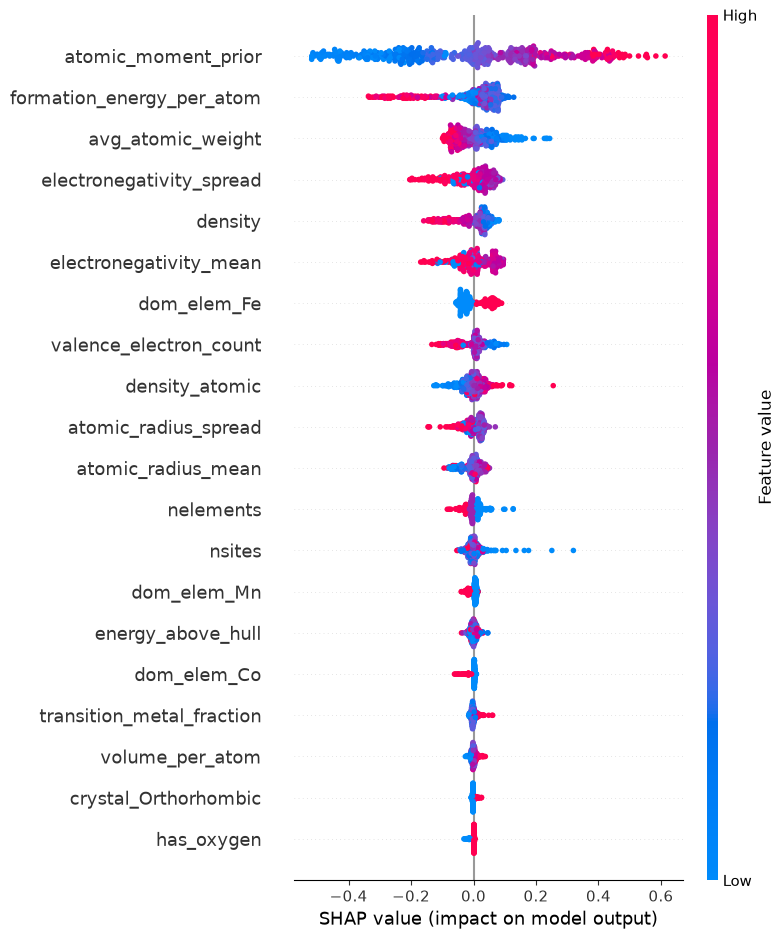

In [22]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("./outputs/shap_summary_plot.png", dpi=150)
print("\nSaved SHAP summary plot to ./outputs/shap_summary_plot.png")
 